--- Model Comparison Table ---
            Model   RMSE (MW)    MAE (MW)  MAPE (%)
 Advanced XGBoost 1949.955742 1455.476604  4.571994
Advanced LightGBM 1948.618328 1456.136382  4.574777


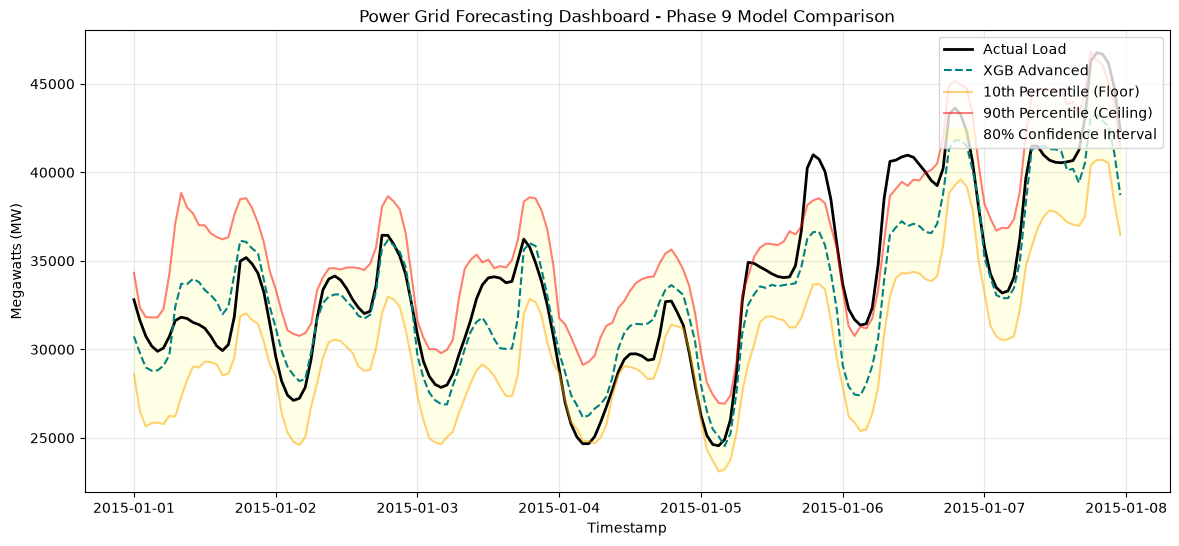

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# 1. Load the data exported from the training notebook
test_adv = pd.read_csv('test_with_predictions.csv', index_col=0, parse_dates=True)

TARGET = 'PJME_MW'

# 2. Calculate Evaluation Metrics Matrix
metrics_data = {
    'Model': ['Advanced XGBoost', 'Advanced LightGBM'],
    'RMSE (MW)': [
        root_mean_squared_error(test_adv[TARGET], test_adv['xgb_advanced_pred']),
        root_mean_squared_error(test_adv[TARGET], test_adv['lgb_advanced_pred'])
    ],
    'MAE (MW)': [
        mean_absolute_error(test_adv[TARGET], test_adv['xgb_advanced_pred']),
        mean_absolute_error(test_adv[TARGET], test_adv['lgb_advanced_pred'])
    ],
    'MAPE (%)': [
        mean_absolute_percentage_error(test_adv[TARGET], test_adv['xgb_advanced_pred']) * 100,
        mean_absolute_percentage_error(test_adv[TARGET], test_adv['lgb_advanced_pred']) * 100
    ]
}

metrics_df = pd.DataFrame(metrics_data)
print("--- Model Comparison Table ---")
print(metrics_df.to_string(index=False))

# 3. Plot a 1-Week Diagnostic Zoom-in Chart
plt.figure(figsize=(14, 6))
zoom_df = test_adv.loc['2015-01-01':'2015-01-07'] 

plt.plot(zoom_df.index, zoom_df[TARGET], label='Actual Load', color='black', linewidth=2)
plt.plot(zoom_df.index, zoom_df['xgb_advanced_pred'], label='XGB Advanced', color='teal', linestyle='--')
plt.plot(zoom_df.index, zoom_df['lower_bound'], label='10th Percentile (Floor)', color='orange', alpha=0.5)
plt.plot(zoom_df.index, zoom_df['upper_bound'], label='90th Percentile (Ceiling)', color='red', alpha=0.5)

plt.fill_between(zoom_df.index, zoom_df['lower_bound'], zoom_df['upper_bound'], color='yellow', alpha=0.1, label='80% Confidence Interval')
plt.title('Power Grid Forecasting Dashboard - Phase 9 Model Comparison')
plt.ylabel('Megawatts (MW)')
plt.xlabel('Timestamp')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

--- Advanced XGBoost Performance Summary ---
RMSE: 1949.96 MW
MAE:  1455.48 MW
MAPE: 4.57%
--------------------------------------------


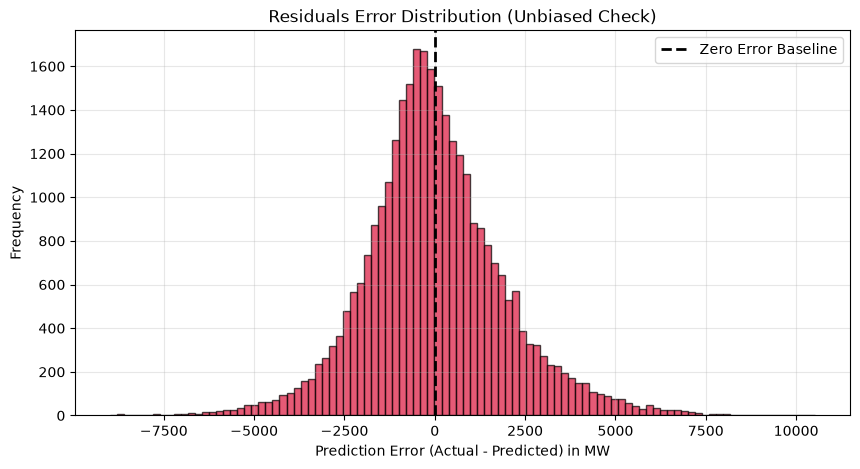

Mean Error Bias: -0.61 MW


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# 1. Load the data safely from disk
test_adv = pd.read_csv('test_with_predictions.csv', index_col=0, parse_dates=True)
TARGET = 'PJME_MW'

# 2. Calculate Evaluation Metrics for XGBoost Advanced
rmse_val = root_mean_squared_error(test_adv[TARGET], test_adv['xgb_advanced_pred'])
mae_val = mean_absolute_error(test_adv[TARGET], test_adv['xgb_advanced_pred'])
mape_val = mean_absolute_percentage_error(test_adv[TARGET], test_adv['xgb_advanced_pred']) * 100

print("--- Advanced XGBoost Performance Summary ---")
print(f"RMSE: {rmse_val:.2f} MW")
print(f"MAE:  {mae_val:.2f} MW")
print(f"MAPE: {mape_val:.2f}%")
print("--------------------------------------------")

# 3. Plot the Residual Distribution to check for bias
test_adv['residuals'] = test_adv[TARGET] - test_adv['xgb_advanced_pred']

plt.figure(figsize=(10, 5))
plt.hist(test_adv['residuals'], bins=100, color='crimson', edgecolor='k', alpha=0.7)
plt.axvline(0, color='black', linestyle='--', linewidth=2, label='Zero Error Baseline')
plt.title('Residuals Error Distribution (Unbiased Check)')
plt.xlabel('Prediction Error (Actual - Predicted) in MW')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Mean Error Bias: {test_adv['residuals'].mean():.2f} MW")